# The Heston Stochastic Volatility Model

This notebook simulates the **Heston (1993)** model, prices options by Monte Carlo on the simulated paths, extracts the **implied-volatility smile**, and shows how the smile's shape comes from the model's parameters — in particular the **leverage effect** from negative correlation between price and volatility.

## Why Heston, and why it matters
Black-Scholes assumes volatility is **constant**. Real markets violate this: options at different strikes trade at different implied volatilities — the **volatility smile / skew**. Black-Scholes can't produce a smile; it predicts a flat line.

Heston fixes this by making volatility itself **random** — a second stochastic process, correlated with the price. This single change generates a realistic smile, and the parameters map to features traders care about:
- **correlation (ρ)** controls the *skew* (the tilt of the smile)
- **vol-of-vol (ξ)** controls the *curvature* (how pronounced the smile is)

## Pipeline
1. **The model** — two coupled SDEs for price and variance
2. **Simulation** — Euler discretization with full truncation to keep variance non-negative
3. **Monte Carlo pricing** — price European calls across strikes from the simulated terminal prices
4. **Implied volatility** — back-solve Black-Scholes to turn each price into an implied vol
5. **The smile** — plot implied vol vs strike, and show how ρ and ξ reshape it

In [1]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import brentq
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams["figure.figsize"] = (9, 5)

---
# 1. The Model: two coupled stochastic differential equations

Heston models the stock price $S_t$ and its **instantaneous variance** $v_t$ as two correlated processes:

$$dS_t = r\, S_t\, dt + \sqrt{v_t}\, S_t\, dW_t^S$$

$$dv_t = \kappa(\theta - v_t)\, dt + \xi \sqrt{v_t}\, dW_t^v$$

$$\text{with } \mathrm{Corr}(dW_t^S, dW_t^v) = \rho$$

### Reading each piece

**Price equation** — the same geometric Brownian motion as Black-Scholes, *except* the volatility $\sqrt{v_t}$ is no longer constant; it changes over time as $v_t$ moves.

**Variance equation** — a **mean-reverting** (Cox-Ingersoll-Ross) process:
- $\kappa$ — *mean-reversion speed*: how fast variance is pulled back toward its long-run level.
- $\theta$ — *long-run variance*: the level variance reverts to.
- $\xi$ (xi) — *vol-of-vol*: how noisy the variance process itself is. Larger $\xi$ → more curvature in the smile.
- The $\sqrt{v_t}$ factor means variance moves less when it's near zero, which helps keep it positive.

**Correlation $\rho$** — the crucial one. It links the two random shocks. When $\rho < 0$, a downward price shock tends to coincide with an *upward* volatility shock — exactly the **leverage effect** seen in equity markets (markets get more volatile when they fall). This negative correlation is what tilts the smile into a skew.

### The Feller condition
$2\kappa\theta \ge \xi^2$ ensures the true variance process never hits zero. In discrete simulation we can still get negative draws, which is why we need a truncation scheme (next section).

In [2]:
# Heston parameters (a typical equity-like calibration).
S0    = 100.0     # initial stock price
r     = 0.03      # risk-free rate
v0    = 0.04      # initial variance (vol = sqrt(0.04) = 20%)
kappa = 2.0       # mean-reversion speed
theta = 0.04      # long-run variance
xi    = 0.5       # vol-of-vol
rho   = -0.7      # price/vol correlation (negative = leverage effect)
T     = 1.0       # time horizon (years)

feller = 2 * kappa * theta - xi**2
print(f"Feller condition 2*kappa*theta - xi^2 = {feller:.3f} "
      f"({'satisfied' if feller >= 0 else 'VIOLATED — variance may hit zero'})")

Feller condition 2*kappa*theta - xi^2 = -0.090 (VIOLATED — variance may hit zero)


---
# 2. Simulation: Euler discretization with full truncation

We can't solve these SDEs in closed form, so we simulate them step by step. Split $[0,T]$ into $N$ small steps of size $dt$. At each step:

1. Draw two **correlated** normal shocks $Z^S, Z^v$ with correlation $\rho$.
2. Update variance, then price.

### Generating correlated shocks
Draw two independent normals $Z_1, Z_2$, then combine:
$$Z^S = Z_1, \qquad Z^v = \rho Z_1 + \sqrt{1-\rho^2}\, Z_2$$
This gives two normals with exactly correlation $\rho$ (a 2-D Cholesky factorization).

### The negative-variance problem and "full truncation"
The Euler update for variance can produce a **negative** value (a large downward shock), which is nonsensical and breaks the $\sqrt{v_t}$ term. The **full-truncation** scheme handles this simply: wherever variance goes negative, use $v^+ = \max(v, 0)$ in the dynamics. It's the standard, robust fix and introduces minimal bias.

### Why log-price
We simulate $\log S_t$ rather than $S_t$ directly. The log-price update is exact for the GBM part given $v_t$, avoids negative prices entirely, and is numerically more stable.

In [3]:
def simulate_heston(S0, v0, r, kappa, theta, xi, rho, T, n_paths=50000, n_steps=252, seed=0):
    rng = np.random.default_rng(seed)
    dt = T / n_steps
    sqrt_dt = np.sqrt(dt)

    log_S = np.full(n_paths, np.log(S0))
    v = np.full(n_paths, v0)
    v_paths = np.empty((n_paths, n_steps + 1))
    v_paths[:, 0] = v0

    for t in range(1, n_steps + 1):
        # Two correlated normal shocks.
        z1 = rng.standard_normal(n_paths)
        z2 = rng.standard_normal(n_paths)
        zS = z1
        zv = rho * z1 + np.sqrt(1 - rho**2) * z2

        # Full truncation: use max(v, 0) wherever v appears under a sqrt.
        v_pos = np.maximum(v, 0.0)
        sqrt_v = np.sqrt(v_pos)

        # Variance update (CIR Euler step).
        v = v + kappa * (theta - v_pos) * dt + xi * sqrt_v * sqrt_dt * zv

        # Log-price update (uses the variance from the start of the step).
        log_S = log_S + (r - 0.5 * v_pos) * dt + sqrt_v * sqrt_dt * zS

        v_paths[:, t] = v

    return np.exp(log_S), v_paths


S_T, v_paths = simulate_heston(S0, v0, r, kappa, theta, xi, rho, T)
print(f"Simulated {len(S_T):,} terminal prices")
print(f"Terminal price: mean={S_T.mean():.2f}, std={S_T.std():.2f}")
print(f"Expected mean under risk-neutral drift: {S0 * np.exp(r*T):.2f}  "
      f"(should be close — sanity check on the drift)")

Simulated 50,000 terminal prices
Terminal price: mean=103.19, std=18.90
Expected mean under risk-neutral drift: 103.05  (should be close — sanity check on the drift)


### a few variance paths

Variance should wobble around its long-run level $\theta$ and stay non-negative. Notice it mean-reverts — when it wanders high or low, it gets pulled back.

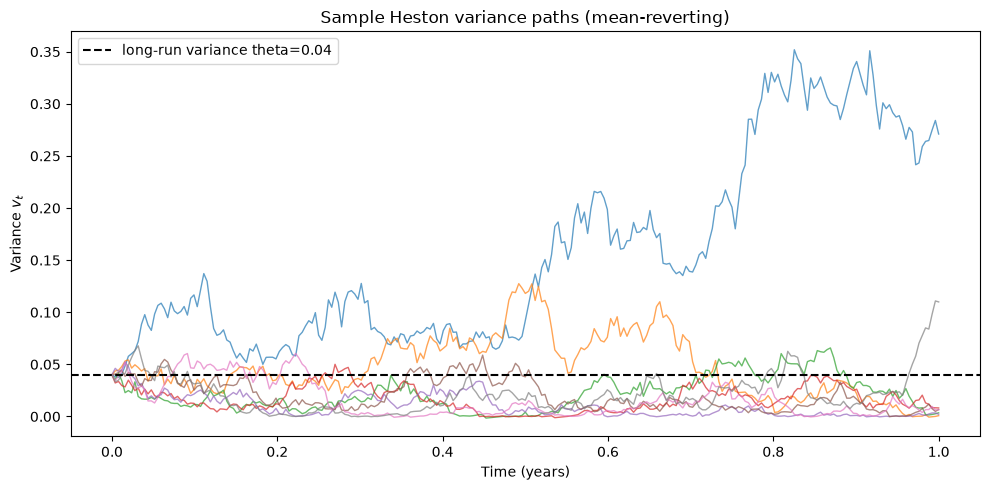

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
time_grid = np.linspace(0, T, v_paths.shape[1])
for i in range(8):
    ax.plot(time_grid, v_paths[i], alpha=0.7, lw=1)
ax.axhline(theta, color="black", ls="--", label=f"long-run variance theta={theta}")
ax.set_xlabel("Time (years)"); ax.set_ylabel("Variance $v_t$")
ax.set_title("Sample Heston variance paths (mean-reverting)")
ax.legend(); plt.tight_layout(); plt.show()

---
# 3. Monte Carlo pricing across strikes

With terminal prices $S_T$ in hand, a European **call** with strike $K$ is priced by averaging its discounted payoff over all paths:

$$C(K) = e^{-rT}\, \mathbb{E}\big[(S_T - K)^+\big] \approx e^{-rT}\, \frac{1}{M}\sum_{i=1}^{M} \max(S_T^{(i)} - K, 0)$$

We reuse the **same** set of simulated terminal prices for every strike — this is efficient and makes the prices across strikes consistent (they share the same random draws).

In [5]:
def mc_call_price(S_T, K, r, T):
    """Monte Carlo European call price from terminal prices."""
    payoff = np.maximum(S_T - K, 0.0)
    return np.exp(-r * T) * payoff.mean()


# Price across a range of strikes (80 to 120 = moneyness 0.8 to 1.2).
strikes = np.linspace(80, 120, 21)
call_prices = np.array([mc_call_price(S_T, K, r, T) for K in strikes])

for K, C in zip(strikes[::4], call_prices[::4]):
    print(f"  K={K:6.1f}   call price = {C:7.4f}")

  K=  80.0   call price = 23.9817
  K=  88.0   call price = 17.3987
  K=  96.0   call price = 11.5349
  K= 104.0   call price =  6.7119
  K= 112.0   call price =  3.2597
  K= 120.0   call price =  1.2795


---
# 4. Implied volatility: back-solving Black-Scholes

Here is the key conceptual step. We have **Heston** prices. We now ask: *what constant Black-Scholes volatility would reproduce each of these prices?*

That number is the **implied volatility**. For each strike:
1. Take the Heston Monte Carlo price $C(K)$.
2. Find the $\sigma$ such that the Black-Scholes formula gives exactly that price.
3. Solve numerically (Brent's method — robust root-finding on a bracketed interval).

If volatility were truly constant (Black-Scholes world), every strike would imply the **same** $\sigma$ — a flat line. Because Heston has stochastic, correlated volatility, different strikes imply **different** vols — that's the smile.

In [6]:
def bs_call(S, K, T, r, sigma):
    """Black-Scholes European call price."""
    if sigma <= 0 or T <= 0:
        return max(S - K * np.exp(-r * T), 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def implied_vol(price, S, K, T, r):
    """Back-solve for the Black-Scholes implied volatility via Brent's method."""
    intrinsic = max(S - K * np.exp(-r * T), 0.0)
    if price <= intrinsic + 1e-10:        # price at/below intrinsic -> no solution
        return np.nan
    try:
        # Find sigma in [0.1%, 500%] that matches the target price.
        return brentq(lambda s: bs_call(S, K, T, r, s) - price, 1e-4, 5.0,
                      maxiter=200, xtol=1e-8)
    except (ValueError, RuntimeError):
        return np.nan


ivs = np.array([implied_vol(C, S0, K, T, r) for C, K in zip(call_prices, strikes)])
for K, iv in zip(strikes[::4], ivs[::4]):
    print(f"  K={K:6.1f}   implied vol = {iv*100:5.2f}%")

  K=  80.0   implied vol = 24.19%
  K=  88.0   implied vol = 21.96%
  K=  96.0   implied vol = 19.85%
  K= 104.0   implied vol = 17.90%
  K= 112.0   implied vol = 16.20%
  K= 120.0   implied vol = 14.89%


---
# 5. The volatility smile

Now plot implied vol against strike. The flat dashed line is what Black-Scholes predicts (constant vol). The Heston curve is **not** flat — that's the whole point.

With $\rho < 0$ (our leverage-effect setting), the curve is **tilted**: implied vol is higher for low strikes (out-of-the-money puts / in-the-money calls) than for high strikes. This is the **volatility skew** characteristic of equity index options.

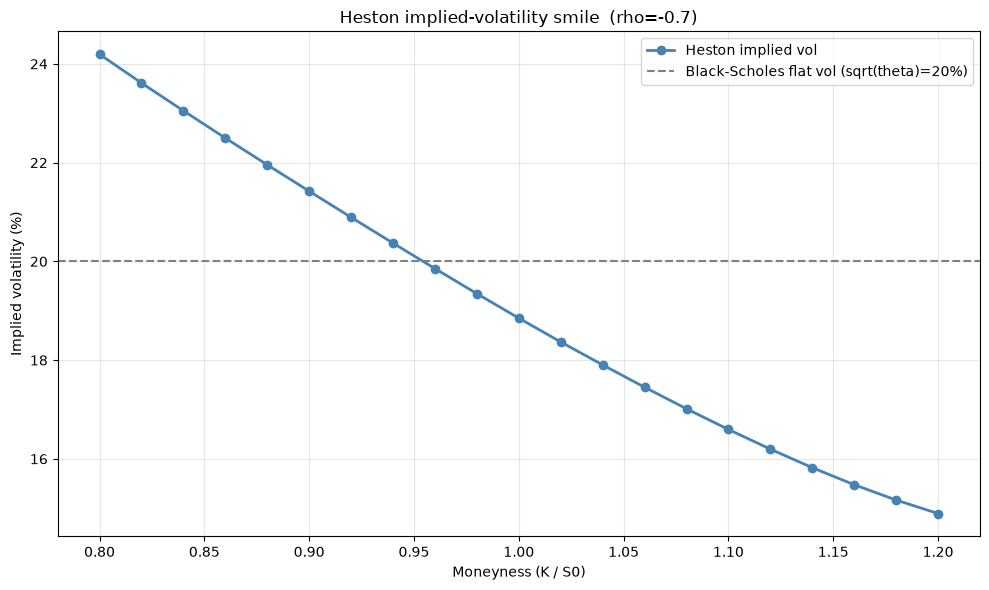

In [7]:
moneyness = strikes / S0
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(moneyness, ivs * 100, "o-", color="steelblue", lw=2, label="Heston implied vol")
ax.axhline(np.sqrt(theta) * 100, color="gray", ls="--",
           label=f"Black-Scholes flat vol (sqrt(theta)={np.sqrt(theta)*100:.0f}%)")
ax.set_xlabel("Moneyness (K / S0)")
ax.set_ylabel("Implied volatility (%)")
ax.set_title(f"Heston implied-volatility smile  (rho={rho})")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
# 6. How the parameters reshape the smile

The two parameters that control the smile's *shape* are correlation $\rho$ (the skew) and vol-of-vol $\xi$ (the curvature). Let's vary each and watch the smile respond — this is the most insightful part for an interview, because it connects an abstract parameter to an observable market feature.

### Correlation ρ controls the skew (tilt)

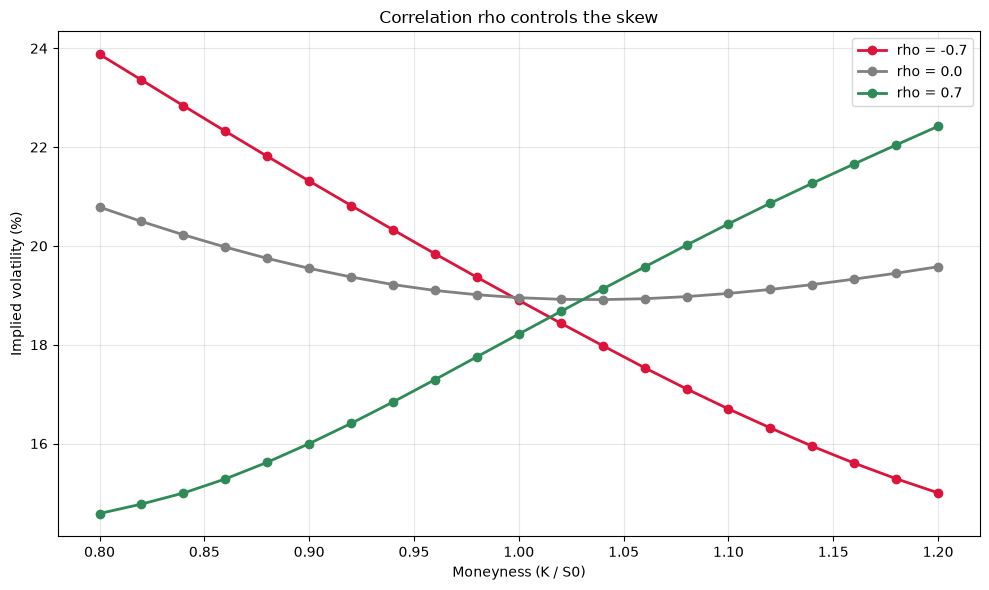

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
for rho_test, color in [(-0.7, "crimson"), (0.0, "gray"), (0.7, "seagreen")]:
    S_T_r, _ = simulate_heston(S0, v0, r, kappa, theta, xi, rho_test, T,
                               n_paths=50000, seed=1)
    prices_r = np.array([mc_call_price(S_T_r, K, r, T) for K in strikes])
    ivs_r = np.array([implied_vol(C, S0, K, T, r) for C, K in zip(prices_r, strikes)])
    ax.plot(moneyness, ivs_r * 100, "o-", color=color, lw=2, label=f"rho = {rho_test}")
ax.set_xlabel("Moneyness (K / S0)"); ax.set_ylabel("Implied volatility (%)")
ax.set_title("Correlation rho controls the skew")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**What you see:** negative ρ tilts the smile downward-to-the-right (high vol at low strikes) — the equity skew. Zero ρ gives a roughly symmetric smile. Positive ρ tilts it the other way. The sign of ρ literally sets the direction of the skew, which is why calibrating ρ to market data is how you match the observed skew.

### Vol-of-vol ξ controls the curvature

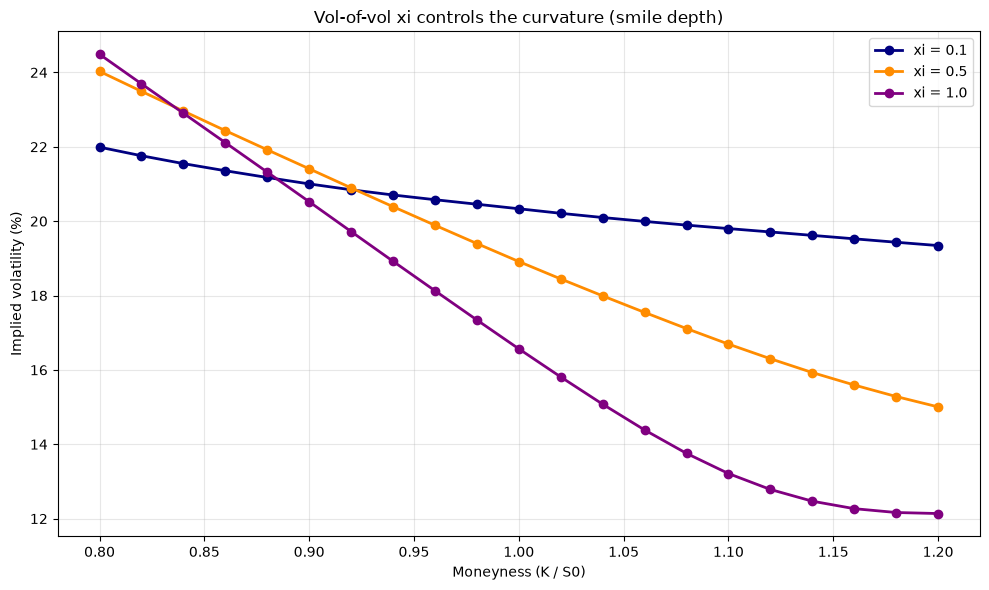

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
for xi_test, color in [(0.1, "navy"), (0.5, "darkorange"), (1.0, "purple")]:
    S_T_x, _ = simulate_heston(S0, v0, r, kappa, theta, xi_test, rho, T,
                               n_paths=50000, seed=2)
    prices_x = np.array([mc_call_price(S_T_x, K, r, T) for K in strikes])
    ivs_x = np.array([implied_vol(C, S0, K, T, r) for C, K in zip(prices_x, strikes)])
    ax.plot(moneyness, ivs_x * 100, "o-", color=color, lw=2, label=f"xi = {xi_test}")
ax.set_xlabel("Moneyness (K / S0)"); ax.set_ylabel("Implied volatility (%)")
ax.set_title("Vol-of-vol xi controls the curvature (smile depth)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**What you see:** small ξ gives an almost flat line (volatility barely moves, so we're near Black-Scholes). Larger ξ deepens the curvature — more uncertainty about future volatility makes far-from-the-money options relatively more expensive, lifting their implied vols and bending the smile.